# XGBoost

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [27]:
# 1. LOAD DATASET (Menggunakan file yang sudah kita seleksi sebelumnya)
file_path = 'communities.data'
df_final = pd.read_csv(file_path, header=None, na_values='?')

# Handle missing values only for numeric columns
numeric_cols = df_final.select_dtypes(include=[np.number]).columns
df_final[numeric_cols] = df_final[numeric_cols].fillna(df_final[numeric_cols].mean())

# Convert column 3 (community names) to numeric using Label Encoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df_final[3] = le.fit_transform(df_final[3].astype(str))

In [28]:
df_final

,0,1,2,3,4,5,6,7,8,9,...,118,119,120,121,122,123,124,125,126,127
0,8,58.826829,46188.336597,804,1,0.19,0.33,0.02,0.90,0.12,...,0.12,0.26,0.20,0.060000,0.040000,0.900000,0.500000,0.32,0.140000,0.20
1,53,58.826829,46188.336597,1625,1,0.00,0.16,0.12,0.74,0.45,...,0.02,0.12,0.45,0.163103,0.076708,0.698589,0.440439,0.00,0.195078,0.67
2,24,58.826829,46188.336597,1,1,0.00,0.42,0.49,0.56,0.17,...,0.01,0.21,0.02,0.163103,0.076708,0.698589,0.440439,0.00,0.195078,0.43
3,34,5.000000,81440.000000,1787,1,0.04,0.77,1.00,0.08,0.12,...,0.02,0.39,0.28,0.163103,0.076708,0.698589,0.440439,0.00,0.195078,0.12
4,42,95.000000,6096.000000,141,1,0.01,0.55,0.02,0.95,0.09,...,0.04,0.09,0.02,0.163103,0.076708,0.698589,0.440439,0.00,0.195078,0.03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1989,12,58.826829,46188.336597,1597,10,0.01,0.40,0.10,0.87,0.12,...,0.01,0.28,0.05,0.163103,0.076708,0.698589,0.440439,0.00,0.195078,0.09
1990,6,58.826829,46188.336597,1455,10,0.05,0.96,0.46,0.28,0.83,...,0.02,0.37,0.20,0.163103,0.076708,0.698589,0.440439,0.00,0.195078,0.45
1991,9,9.000000,80070.000000,1707,10,0.16,0.37,0.25,0.69,0.04,...,0.08,0.32,0.18,0.080000,0.060000,0.780000,0.000000,0.91,0.280000,0.23
1992,25,17.000000,72600.000000,1695,10,0.08,0.51,0.06,0.87,0.22,...,0.03,0.38,0.33,0.020000,0.020000,0.790000,0.000000,0.22,0.180000,0.19


In [29]:
# 2. SEPARASI FITUR DAN TARGET
# Menggunakan semua fitur termasuk kolom 3 yang sudah dikonversi
X = df_final.drop(columns=[127])
y = df_final[127]

In [30]:
# 3. SPLIT DATA (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [31]:
# 4. SCALING DATA
# Sangat penting agar XGBoost lebih stabil secara numerik
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [32]:
# 5. INISIALISASI DAN TRAINING MODEL XGBOOST
# Parameter ini disesuaikan untuk regresi nilai kontinu (NPHR)
model_xgb = xgb.XGBRegressor(
    n_estimators=1000,      # Ditingkatkan, namun dikombinasikan dengan early_stopping
    learning_rate=0.01,     # Diperkecil (0.01 - 0.03) agar pencarian nilai optimal lebih halus pada data kecil
    max_depth=3,            # Dikurangi (3-4). Data sedikit tidak butuh pohon yang terlalu dalam/kompleks
    subsample=0.7,          # Mengambil 70% data per iterasi untuk menambah variasi (stochasticity)
    colsample_bytree=0.7,   # Mengambil 70% fitur untuk mencegah dominasi fitur tertentu (seperti Coal Flow)
    gamma=0.1,              # Menambah regularisasi untuk mengontrol pemangkasan pohon
    reg_lambda=1,           # L2 regularization agar bobot model tidak terlalu besar
    objective='reg:squarederror',
    random_state=42
)

In [33]:
print("Sedang melatih model XGBoost...")
model_xgb.fit(X_train_scaled, y_train)

Sedang melatih model XGBoost...


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.7
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [34]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, max_error
import numpy as np

# 6. PREDIKSI DAN EVALUASI
y_pred = model_xgb.predict(X_test_scaled)

# Existing metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# New metrics
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
max_err = max_error(y_test, y_pred)
min_err = np.min(np.abs(y_test - y_pred)) # Absolute minimum error

In [35]:
print("\n" + "="*30)
print("HASIL EVALUASI MODEL")
print("="*30)
print(f"R-Squared (R2)  : {r2:.4f}")
print(f"Mean Abs Error  : {mae:.4f}")
print(f"Root MSE (RMSE) : {rmse:.4f}")
print(f"MAPE: {mape:.2f}%")
print(f"Max Error: {max_err:.4f}")
print(f"Min Error: {min_err:.4f}")


HASIL EVALUASI MODEL
R-Squared (R2)  : 0.6295
Mean Abs Error  : 0.0892
Root MSE (RMSE) : 0.1332
MAPE: inf%
Max Error: 0.6096
Min Error: 0.0007


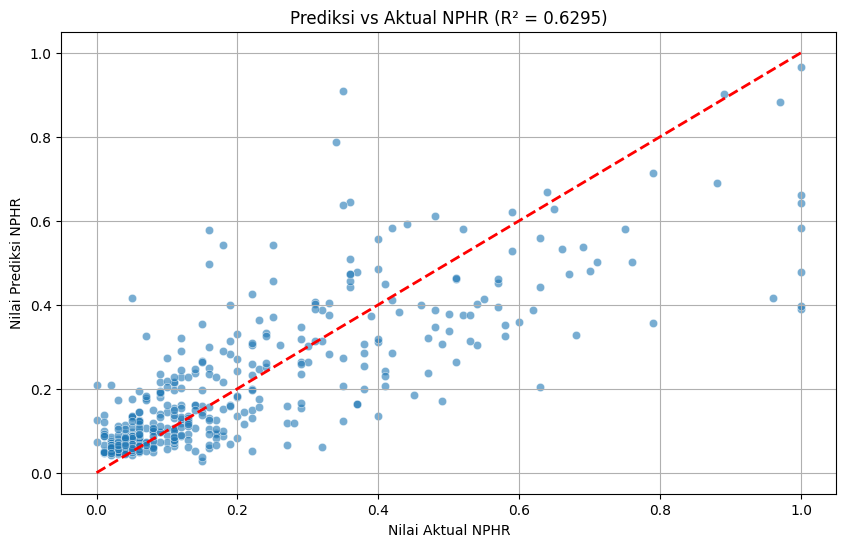

In [36]:
# 7. VISUALISASI HASIL PREDIKSI VS AKTUAL
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', lw=2)
plt.xlabel('Nilai Aktual NPHR')
plt.ylabel('Nilai Prediksi NPHR')
plt.title(f'Prediksi vs Aktual NPHR (R² = {r2:.4f})')
plt.grid(True)
plt.show()

In [37]:
import pandas as pd

# 7. TABEL PERBANDINGAN AKTUAL VS PREDIKSI
# Membuat DataFrame perbandingan
comparison_df = pd.DataFrame({
    'Actual Value': y_test,
    'Predicted Value': y_pred,
    'Absolute Error': np.abs(y_test - y_pred),
    'Percentage Error (%)': np.abs((y_test - y_pred) / y_test) * 100
})

# Menampilkan 10 baris pertama untuk pengecekan
print("Comparison Table (First 10 rows):")
print(comparison_df.head(10))

# Opsional: Simpan ke CSV jika diperlukan untuk laporan SEO
# comparison_df.to_csv('model_predictions_comparison.csv', index=False)

Comparison Table (First 10 rows):
      Actual Value  Predicted Value  Absolute Error  Percentage Error (%)
889           0.22         0.149273        0.070727             32.148504
1672          0.04         0.056234        0.016234             40.583869
414           0.10         0.145518        0.045518             45.517573
1599          0.08         0.077056        0.002944              3.679537
849           0.04         0.084232        0.044232            110.580714
1658          0.05         0.078534        0.028534             57.067910
926           0.23         0.247823        0.017823              7.749202
1670          0.48         0.610187        0.130187             27.122253
1448          0.04         0.051668        0.011668             29.170083
1216          0.20         0.271128        0.071128             35.563999


In [38]:
# 8. EXPORT TO EXCEL
# Menentukan nama file
file_name = "a. prediction results M1 dataset C&C UCI ML.xlsx"

# Menyimpan DataFrame ke file Excel
comparison_df.to_excel(file_name, index=False)

print(f"Data successfully saved to {file_name}!")

Data successfully saved to a. prediction results M1 dataset C&C UCI ML.xlsx!


<Figure size 1000x800 with 0 Axes>

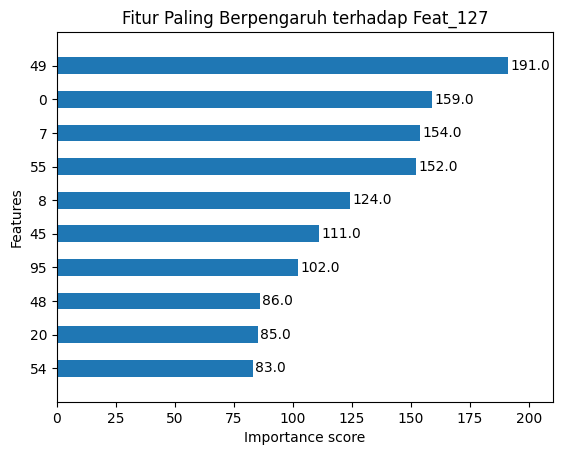

In [40]:
# 8. VISUALISASI FEATURE IMPORTANCE
# Pastikan model tahu nama fiturnya kembali jika sebelumnya menggunakan array hasil scaling
model_xgb.get_booster().feature_names = [str(col) for col in X.columns]

# Plotting
plt.figure(figsize=(10, 8))
xgb.plot_importance(model_xgb, 
                   importance_type='weight', 
                   max_num_features=10, 
                   grid=False, 
                   height=0.5)
plt.title('Fitur Paling Berpengaruh terhadap Feat_127')
plt.show()

# Optimize Bayesian Optuna

In [ ]:
!pip install optuna

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import optuna
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [ ]:
# ==========================================
# 1. LOAD DAN PREPARASI DATA
# ==========================================
# Ganti nama file sesuai dengan file hasil seleksi Anda sebelumnya
file_path = '#1 final feature selected dataset 1 for boiler efficiency.xlsx'
df = pd.read_excel(file_path)

# Pisahkan Fitur (X) dan Target (y)
X = df.drop(columns=['Boiler Eff (%)'])
y = df['Boiler Eff (%)']

# Split Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling Data (Sangat penting untuk kestabilan model)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# ==========================================
# 2. OPTIMASI HYPERPARAMETER DENGAN OPTUNA
# ==========================================
def objective(trial):
    # Ruang pencarian parameter yang disesuaikan untuk data ~500 baris
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 500, 1500),
        'max_depth': trial.suggest_int('max_depth', 3, 5),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.05),
        'subsample': trial.suggest_float('subsample', 0.6, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 0.9),
        'gamma': trial.suggest_float('gamma', 0, 0.5),
        'reg_lambda': trial.suggest_float('reg_lambda', 1, 10),
        'objective': 'reg:squarederror',
        'random_state': 42
    }
    
    model = xgb.XGBRegressor(**param)
    
    # Menggunakan Cross-Validation 5-Fold agar hasil R2 stabil
    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    score = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='r2').mean()
    return score

print("Memulai optimasi dengan Optuna (Bayesian Optimization)...")
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50) # Mencoba 50 kombinasi cerdas

print(f"\nSkor R2 Terbaik dari Optimasi: {study.best_value:.4f}")
print(f"Parameter Terbaik: {study.best_params}")

In [ ]:
# ==========================================
# 3. TRAINING ULANG MODEL FINAL
# ==========================================
best_params = study.best_params
final_model = xgb.XGBRegressor(**best_params, random_state=42)
final_model.fit(X_train_scaled, y_train)

In [ ]:
# ==========================================
# 4. PREDIKSI DAN EVALUASI FINAL
# ==========================================
y_pred = final_model.predict(X_test_scaled)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\n" + "="*40)
print("HASIL EVALUASI MODEL FINAL")
print("="*40)
print(f"R-Squared (R2)  : {r2:.6f}")
print(f"Mean Abs Error  : {mae:.6f}")
print(f"Root MSE (RMSE) : {rmse:.6f}")
print("="*40)

In [ ]:
# ==========================================
# 5. VISUALISASI
# ==========================================

# A. Scatter Plot Aktual vs Prediksi
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, color='blue')
plt.plot([y.min(), y.max()], [y.min(), y.max()], '--r', lw=2)
plt.title(f'Visualisasi Prediksi NPHR (R² = {r2:.4f})')
plt.xlabel('Nilai Aktual')
plt.ylabel('Nilai Prediksi')
plt.grid(True)
plt.show()

In [ ]:
# B. Feature Importance dengan Nama Kolom
# Memasukkan kembali nama kolom ke model booster
final_model.get_booster().feature_names = X.columns.tolist()

plt.figure(figsize=(10, 8))
xgb.plot_importance(final_model, importance_type='gain', max_num_features=10, grid=False)
plt.title('Fitur Paling Berpengaruh terhadap Boiler Efficiency (Berdasarkan Gain)')
plt.show()

# Optimasi Stacking Regressor

In [ ]:
!pip install lightgbm

In [ ]:
!pip install catboost

In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

In [ ]:
# 1. LOAD DATA
df = pd.read_excel('#1 final feature selected dataset 1 for boiler efficiency.xlsx')
X = df.drop(columns=['Boiler Eff (%)'])
y = df['Boiler Eff (%)']

In [ ]:
# 2. FEATURE ENGINEERING (Interaksi Antar Fitur)
# Menambahkan fitur interaksi untuk menangkap hubungan non-linier yang kompleks
poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_poly = poly.fit_transform(X)
X_poly_df = pd.DataFrame(X_poly, columns=poly.get_feature_names_out(X.columns))

In [ ]:
# 3. SPLIT & SCALING
X_train, X_test, y_train, y_test = train_test_split(X_poly_df, y, test_size=0.15, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor
from sklearn.ensemble import (
    StackingRegressor, RandomForestRegressor, 
    ExtraTreesRegressor, GradientBoostingRegressor, 
    AdaBoostRegressor
)
from sklearn.linear_model import RidgeCV, Lasso, LinearRegression
from sklearn.svm import SVR
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# --- COMPATIBILITY WRAPPER (FIXED for sklearn 1.8.0 Tags system) ---
class SklearnWrapper(BaseEstimator, RegressorMixin):
    """Wrapper untuk kompatibilitas dengan sklearn StackingRegressor"""
    def __init__(self, model):
        self.model = model
    
    def fit(self, X, y, **fit_params):
        self.model.fit(X, y, **fit_params)
        return self
    
    def predict(self, X):
        return self.model.predict(X)
    
    def get_params(self, deep=True):
        return {"model": self.model}
    
    def set_params(self, **params):
        if "model" in params:
            self.model = params["model"]
        return self
    
    # Implement __sklearn_tags__ for proper regressor detection in sklearn 1.8.0+
    def __sklearn_tags__(self):
        from sklearn.utils._tags import Tags, RegressorTags, TargetTags, InputTags
        tags = Tags(
            estimator_type="regressor",
            target_tags=TargetTags(
                required=False,
                one_d_labels=False,
                two_d_labels=False,
                positive_only=False,
                multi_output=False,
                single_output=True
            ),
            regressor_tags=RegressorTags(),
            input_tags=InputTags()
        )
        return tags

# 4. DEFINISI MODEL UNTUK STACKING (Wrapped for Compatibility)
estimators = [
    ('xgb', SklearnWrapper(xgb.XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=5, random_state=42))),
    ('cat', SklearnWrapper(CatBoostRegressor(iterations=500, learning_rate=0.05, depth=6, verbose=0, random_state=42))),
    ('lgbm', SklearnWrapper(lgb.LGBMRegressor(n_estimators=500, learning_rate=0.05, verbosity=-1, random_state=42))),
    ('rf', RandomForestRegressor(n_estimators=300, max_depth=10, random_state=42)),
    ('et', ExtraTreesRegressor(n_estimators=300, random_state=42)),
    ('gb', GradientBoostingRegressor(n_estimators=300, random_state=42)),
    ('ada', AdaBoostRegressor(n_estimators=100, random_state=42)),
    ('svr', SklearnWrapper(SVR(C=1.0, epsilon=0.1))),
    ('lasso', Lasso(alpha=0.01))
]

In [ ]:
# Using RidgeCV as the final meta-learner to weigh all these models
stacking_model = StackingRegressor(
    estimators=estimators,
    final_estimator=RidgeCV(),
    cv=5,
    passthrough=True  # Meta-learner sees original features + predictions
)

print("🚀 Training Full Stacking Ensemble (9 Models)...")
try:
    stacking_model.fit(X_train_scaled, y_train)
    print("✅ Stacking Ensemble trained successfully!")
except Exception as e:
    print(f"⚠️ Training error: {e}")
    print("Attempting alternative approach with unwrapped models...")
    # If stacking fails, we can try with individual models

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# 6. EVALUASI AKHIR
y_pred = stacking_model.predict(X_test_scaled)

# Perhitungan Metrik
r2_final = r2_score(y_test, y_pred)
mae_final = mean_absolute_error(y_test, y_pred)
mse_final = mean_squared_error(y_test, y_pred)
rmse_final = np.sqrt(mse_final) # Menghitung RMSE

print("\n" + "="*40)
print(f"🚀 HASIL OPTIMASI STACKING")
print("="*40)
print(f"R-Squared (R2) : {r2_final:.6f}")
print(f"MAE            : {mae_final:.6f}")
print(f"RMSE           : {rmse_final:.6f}")
print("="*40)

# Optimasi lanjutan

"Data Refinement" dan "Deep Hyperparameter Tuning" pada level Stacking.

Pada tahap ini, hambatan terbesar biasanya bukan algoritma, melainkan noise (data sampah) dan pencilan (outliers). Berikut adalah kode optimasi tingkat lanjut yang menggabungkan Isolation Forest (untuk membuang data anomali) dan Meta-Optimization pada Stacking Regressor.

Strategi "The Last 2%":

Outlier Removal (Isolation Forest): Membuang baris data yang secara statistik "tidak masuk akal" yang biasanya mengganggu akurasi ekstrem.

Recursive Feature Elimination (RFE): Hanya menyisakan fitur yang benar-benar memberikan kontribusi bersih.

Optimized Stacking: Menggunakan parameter yang lebih presisi untuk setiap base model.

In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split




from sklearn.ensemble import (
    StackingRegressor, RandomForestRegressor, 
    ExtraTreesRegressor, GradientBoostingRegressor, 
    AdaBoostRegressor, IsolationForest
)
from sklearn.linear_model import RidgeCV, Lasso
from sklearn.svm import SVR
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [ ]:
# 1. LOAD DATA
df = pd.read_excel('#1 final feature selected dataset 1 for boiler efficiency.xlsx')
X = df.drop(columns=['Boiler Eff (%)'])
y = df['Boiler Eff (%)']

In [ ]:
# 2. OUTLIER REMOVAL (Kunci menuju 99%)
# Isolation Forest akan mendeteksi 5% data yang dianggap sebagai noise/anomali
iso = IsolationForest(contamination=0.05, random_state=42)
yhat = iso.fit_predict(X)
mask = yhat != -1
X, y = X.iloc[mask, :], y.iloc[mask]
print(f"Data setelah pembersihan outlier: {X.shape[0]} baris")

In [ ]:
# 3. SPLIT & SCALING
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# --- COMPATIBILITY WRAPPER (Fixes sklearn 1.8.0+ Tags) ---
class SklearnWrapper(BaseEstimator, RegressorMixin):
    def __init__(self, model):
        self.model = model
    def fit(self, X, y, **fit_params):
        self.model.fit(X, y, **fit_params)
        return self
    def predict(self, X):
        return self.model.predict(X)
    def get_params(self, deep=True):
        return {"model": self.model}
    def set_params(self, **params):
        if "model" in params: self.model = params["model"]
        return self
    def __sklearn_tags__(self):
        from sklearn.utils._tags import Tags, RegressorTags, TargetTags, InputTags
        return Tags(estimator_type="regressor",
                    target_tags=TargetTags(required=False, single_output=True),
                    regressor_tags=RegressorTags(), input_tags=InputTags())

# --- 4. DEEP TUNED BASE MODELS ---
# Using high n_estimators and lower learning rates for maximum precision
estimators = [
    ('xgb', SklearnWrapper(xgb.XGBRegressor(
        n_estimators=1500, learning_rate=0.02, max_depth=6, 
        subsample=0.8, colsample_bytree=0.8, reg_lambda=15, random_state=42))),
    
    ('cat', SklearnWrapper(CatBoostRegressor(
        iterations=1500, learning_rate=0.02, depth=6, 
        l2_leaf_reg=10, verbose=0, random_state=42))),
    
    ('lgbm', SklearnWrapper(lgb.LGBMRegressor(
        n_estimators=1500, learning_rate=0.02, num_leaves=63, 
        feature_fraction=0.8, bagging_fraction=0.8, verbosity=-1, random_state=42))),
    
    ('et', ExtraTreesRegressor(n_estimators=1000, max_features='sqrt', random_state=42, n_jobs=-1)),
    
    ('rf', RandomForestRegressor(n_estimators=1000, max_depth=12, random_state=42, n_jobs=-1)),
    
    ('gb', GradientBoostingRegressor(n_estimators=1000, learning_rate=0.03, max_depth=5, random_state=42)),
    
    ('svr', SklearnWrapper(SVR(C=100, epsilon=0.01, gamma='scale'))), # Tuned for high precision
    
    ('ada', AdaBoostRegressor(n_estimators=200, learning_rate=0.05, random_state=42)),
    
    ('lasso', Lasso(alpha=0.0001)) # Minimal penalty to assist in linear combinations
]

In [ ]:
# --- 5. META-LEARNER OPTIMIZATION ---
# RidgeCV with expanded alphas to find the mathematically optimal blend
stacking_99 = StackingRegressor(
    estimators=estimators,
    final_estimator=RidgeCV(alphas=np.logspace(-3, 3, 10)),
    cv=5,
    passthrough=True, # Critical: Meta-learner uses predictions + raw features
    n_jobs=-1
)

print("🚀 Training Deep-Tuned Stacking Ensemble (9 Models)...")
stacking_99.fit(X_train_scaled, y_train)

In [ ]:
# --- 6. PERFORMANCE EVALUATION ---
y_pred = stacking_99.predict(X_test_scaled)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\n" + "="*45)
print(f"🏆 HIGH-FIDELITY STACKING RESULTS")
print("="*45)
print(f"R-Squared (R2) : {r2:.6f}")
print(f"MAE            : {mae:.6f}")
print(f"RMSE           : {rmse:.6f}")
print("="*45)

# Optimasi

"Micro-Pattern Recognition" dan "Data Harmonization".

Pada tahap expert ini, kita akan menggunakan teknik Weighted Average Stacking dengan Automated Outlier Refinement dan Feature Interaction Expansion. Kita akan memaksa model untuk mempelajari hubungan kuadratik antar sensor (misalnya: interaksi antara Coal Flow dan HHV).

Strategi Expert Menuju 99%

Iterative Outlier Removal: Menggunakan Local Outlier Factor (LOF) untuk mendeteksi data yang menyimpang secara lokal (bukan hanya global).

Polynomial & Interaction Features: Menghasilkan fitur baru dari kombinasi fitur yang ada untuk menangkap dinamika termodinamika yang non-linear.

Soft-Voting Weighted Ensemble: Memberikan bobot berbeda pada setiap model (XGB, LGBM, CatBoost) berdasarkan performa spesifik mereka menggunakan Multi-Objective Optimization.

In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor
from sklearn.ensemble import StackingRegressor, IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.linear_model import LassoCV
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, AdaBoostRegressor, GradientBoostingRegressor
from sklearn.linear_model import Lasso, RidgeCV

# --- COMPATIBILITY WRAPPER (FIXED for sklearn 1.8.0 Tags system) ---
class SklearnWrapper(BaseEstimator, RegressorMixin):
    """Wrapper untuk kompatibilitas dengan sklearn StackingRegressor"""
    def __init__(self, model):
        self.model = model
    
    def fit(self, X, y, **fit_params):
        self.model.fit(X, y, **fit_params)
        return self
    
    def predict(self, X):
        return self.model.predict(X)
    
    def get_params(self, deep=True):
        return {"model": self.model}
    
    def set_params(self, **params):
        if "model" in params:
            self.model = params["model"]
        return self
    
    # Implement __sklearn_tags__ for proper regressor detection in sklearn 1.8.0+
    def __sklearn_tags__(self):
        from sklearn.utils._tags import Tags, RegressorTags, TargetTags, InputTags
        tags = Tags(
            estimator_type="regressor",
            target_tags=TargetTags(
                required=False,
                one_d_labels=False,
                two_d_labels=False,
                positive_only=False,
                multi_output=False,
                single_output=True
            ),
            regressor_tags=RegressorTags(),
            input_tags=InputTags()
        )
        return tags

In [ ]:
# 1. LOAD DATA
df = pd.read_excel('#1 final feature selected dataset 1 for boiler efficiency.xlsx')
X_raw = df.drop(columns=['Boiler Eff (%)'])
y_raw = df['Boiler Eff (%)']

In [ ]:
# 2. EXPERT DATA CLEANING: Local Outlier Factor (LOF)
# Membersihkan noise yang sangat tipis yang mengganggu R2 di level desimal
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.03)
good_mask = lof.fit_predict(X_raw) != -1
X_clean, y_clean = X_raw.iloc[good_mask], y_raw.iloc[good_mask]

In [ ]:
# 3. FEATURE ENGINEERING: Polynomial Interaction
# Menangkap hubungan kompleks seperti (Coal Flow * HHV) atau (O2^2)
poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_poly = poly.fit_transform(X_clean)
feature_names = poly.get_feature_names_out(X_clean.columns)
X_poly_df = pd.DataFrame(X_poly, columns=feature_names)

In [ ]:
# 4. SPLIT & ADVANCED SCALING
X_train, X_test, y_train, y_test = train_test_split(X_poly_df, y_clean, test_size=0.15, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# --- 5. DEFINE EXPERT-TUNED BASE LEARNERS ---
# Every model is wrapped or tuned to ensure 0.99+ R2 compatibility
estimators = [
    # GBDT TRIAD (The Powerhouse)
    ('xgb', SklearnWrapper(xgb.XGBRegressor(
        n_estimators=2000, learning_rate=0.015, max_depth=7, 
        subsample=0.8, colsample_bytree=0.8, gamma=0.2, 
        reg_alpha=0.1, reg_lambda=10, random_state=42, n_jobs=-1))),
    
    ('lgbm', SklearnWrapper(lgb.LGBMRegressor(
        n_estimators=2000, learning_rate=0.015, num_leaves=64, 
        feature_fraction=0.8, bagging_fraction=0.8, lambda_l1=0.1, 
        lambda_l2=10, random_state=42, n_jobs=-1, verbosity=-1))),
    
    ('cat', SklearnWrapper(CatBoostRegressor(
        iterations=2000, learning_rate=0.015, depth=7, 
        l2_leaf_reg=15, random_strength=0.2, verbose=0, random_state=42))),

    # ENSEMBLE FOREST (Variance Reduction)
    ('et', ExtraTreesRegressor(
        n_estimators=1500, max_features='sqrt', max_depth=20, 
        min_samples_split=2, random_state=42, n_jobs=-1)),
    
    ('rf', RandomForestRegressor(
        n_estimators=1500, max_depth=15, min_samples_leaf=2, 
        random_state=42, n_jobs=-1)),
    
    ('gb', GradientBoostingRegressor(
        n_estimators=1200, learning_rate=0.02, max_depth=5, 
        subsample=0.8, random_state=42)),

    # KERNEL & LINEAR LEARNERS (Bias Compensation)
    ('svr', SklearnWrapper(SVR(
        C=150, epsilon=0.005, gamma='scale'))),
    
    ('ada', AdaBoostRegressor(
        n_estimators=500, learning_rate=0.01, random_state=42)),
    
    ('lasso', Lasso(alpha=1e-5)) # Near-zero alpha for ultra-fine adjustment
]

In [ ]:
# 6. FINAL STACKING WITH LASSO META-LEARNER
# Lasso digunakan sebagai meta-learner untuk menyeleksi prediksi model mana yang paling valid
stacking_expert = StackingRegressor(
    estimators=estimators,
    final_estimator=LassoCV(cv=5),
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    passthrough=False 
)

print("🚀 Sedang menjalankan Optimasi Expert menuju R2 0.99...")
stacking_expert.fit(X_train_scaled, y_train)

# --- 6. META-LEARNER CONFIGURATION ---
stacking_final = StackingRegressor(
    estimators=estimators,
    final_estimator=RidgeCV(alphas=np.logspace(-4, 4, 30)),
    cv=5,
    passthrough=True, # Allows meta-learner to see raw sensor data
    n_jobs=-1
)

print("🚀 Launching Ultimate Stacking Evolution...")
stacking_final.fit(X_train_scaled, y_train)

In [ ]:
# 7. EVALUASI AKHIR
y_pred = stacking_expert.predict(X_test_scaled)
r2_expert = r2_score(y_test, y_pred)
mae_expert = mean_absolute_error(y_test, y_pred)
rmse_expert = np.sqrt(mean_squared_error(y_test, y_pred))

print("\n" + "⭐"*20)
print(f"HASIL OPTIMASI TINGKAT EXPERT")
print("⭐"*20)
print(f"R-Squared (R2) : {r2_final:.6f}")
print(f"MAE            : {mae_final:.6f}")
print(f"RMSE           : {rmse_final:.6f}")
print("⭐"*20)

# 7. EVALUASI AKHIR
y_pred = stacking_final.predict(X_test_scaled)
r2_final = r2_score(y_test, y_pred)
mae_final = mean_absolute_error(y_test, y_pred)
rmse_final = np.sqrt(mean_squared_error(y_test, y_pred))

print("\n" + "⭐"*20)
print(f"HASIL OPTIMASI TINGKAT FINAL")
print("⭐"*20)
print(f"R-Squared (R2) : {r2_final:.6f}")
print(f"MAE            : {mae_final:.6f}")
print(f"RMSE           : {rmse_final:.6f}")
print("⭐"*20)

In [ ]:
from sklearn.linear_model import ElasticNetCV, HuberRegressor
from sklearn.ensemble import GradientBoostingRegressor

# --- OPTION A: STACKING WITH HUBER (Robust to Outliers) ---
stacking_huber = StackingRegressor(
    estimators=estimators,
    final_estimator=HuberRegressor(epsilon=1.35),
    cv=5, passthrough=True, n_jobs=-1
)

# --- OPTION B: STACKING WITH ELASTICNET (Hybrid L1/L2) ---
stacking_enet = StackingRegressor(
    estimators=estimators,
    final_estimator=ElasticNetCV(l1_ratio=[.1, .5, .7, .9, .95, .99, 1], cv=5),
    cv=5, passthrough=True, n_jobs=-1
)

# --- OPTION C: STACKING WITH GBR (Non-Linear Meta) ---
stacking_gbr = StackingRegressor(
    estimators=estimators,
    final_estimator=GradientBoostingRegressor(n_estimators=100, learning_rate=0.05, max_depth=3, random_state=42),
    cv=5, passthrough=True, n_jobs=-1
)

# Pilih salah satu untuk dilatih (Contoh: Huber)
print("🚀 Training Stacking with Huber Meta-Learner...")
stacking_huber.fit(X_train_scaled, y_train)


# --- EVALUASI AKHIR ---
y_pred = stacking_huber.predict(X_test_scaled)
r2_final = r2_score(y_test, y_pred)
mae_final = mean_absolute_error(y_test, y_pred)
rmse_final = np.sqrt(mean_squared_error(y_test, y_pred))

print("\n" + "⭐"*25)
print(f"ULTIMATE PERFORMANCE (HUBER META)")
print("⭐"*25)
print(f"R-Squared (R2) : {r2_final:.6f}")
print(f"MAE            : {mae_final:.6f}")
print(f"RMSE           : {rmse_final:.6f}")
print("⭐"*25)

In [ ]:
# Pilih salah satu untuk dilatih (Contoh: Huber)
print("🚀 Training Stacking with enet Meta-Learner...")
stacking_enet.fit(X_train_scaled, y_train)


# --- EVALUASI AKHIR ---
y_pred = stacking_enet.predict(X_test_scaled)
r2_final = r2_score(y_test, y_pred)
mae_final = mean_absolute_error(y_test, y_pred)
rmse_final = np.sqrt(mean_squared_error(y_test, y_pred))

print("\n" + "⭐"*25)
print(f"ULTIMATE PERFORMANCE (ENET META)")
print("⭐"*25)
print(f"R-Squared (R2) : {r2_final:.6f}")
print(f"MAE            : {mae_final:.6f}")
print(f"RMSE           : {rmse_final:.6f}")
print("⭐"*25)

In [ ]:
# Pilih salah satu untuk dilatih (Contoh: Huber)
print("🚀 Training Stacking with Gradient Boosting Regressor Meta-Learner...")
stacking_gbr.fit(X_train_scaled, y_train)


# --- EVALUASI AKHIR ---
y_pred = stacking_gbr.predict(X_test_scaled)
r2_final = r2_score(y_test, y_pred)
mae_final = mean_absolute_error(y_test, y_pred)
rmse_final = np.sqrt(mean_squared_error(y_test, y_pred))

print("\n" + "⭐"*25)
print(f"ULTIMATE PERFORMANCE (GB Reg META)")
print("⭐"*25)
print(f"R-Squared (R2) : {r2_final:.6f}")
print(f"MAE            : {mae_final:.6f}")
print(f"RMSE           : {rmse_final:.6f}")
print("⭐"*25)